# Exploratory analysis of QM9 Dataset

In [5]:
from torch_geometric.datasets import QM9
import torch
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math

In [6]:
dataset = QM9(root='~/miniforge3/envs/GNNOpt/lib/python3.11/site-packages/torch_geometric/datasets')
# Extract HOMO-LUMO gap (index 4 in the target tensor)
#for data in dataset:
#    homo_lumo_gap = data.y[:, 4] # Target property

## Example: first molecule

In [46]:
dataset[0].__getattr__

<bound method Data.__getattr__ of Data(x=[5, 11], edge_index=[2, 8], edge_attr=[8, 4], y=[1, 19], pos=[5, 3], idx=[1], name='gdb_1', z=[5])>

In [8]:
# (N x 11) node feature matrix
dataset[0].x

tensor([[0., 1., 0., 0., 0., 6., 0., 0., 0., 0., 4.],
        [1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]])

In [9]:
# (N x 3) Cartesian coordinates of atoms
dataset[0].pos

tensor([[-1.2700e-02,  1.0858e+00,  8.0000e-03],
        [ 2.2000e-03, -6.0000e-03,  2.0000e-03],
        [ 1.0117e+00,  1.4638e+00,  3.0000e-04],
        [-5.4080e-01,  1.4475e+00, -8.7660e-01],
        [-5.2380e-01,  1.4379e+00,  9.0640e-01]])

In [10]:
# (2 x E) connectivity matrix
dataset[0].edge_index

tensor([[0, 0, 0, 0, 1, 2, 3, 4],
        [1, 2, 3, 4, 0, 0, 0, 0]])

In [11]:
# (E x 4) edge attributes where (single/double/triple/aromatic) are the four columns
dataset[0].edge_attr

tensor([[1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.]])

In [12]:
# (1 x 19) 19 DFT properties; 4 is the HOMO-LUMO gap we're targeting
dataset[0].y[0,4]

tensor(13.7363)

In [13]:
# [N] list of atomic numbers in molecule
dataset[0].z

tensor([6, 1, 1, 1, 1])

## Distributions of features & labels

### Atom identities

In [14]:
atom_indices = []
for data in dataset:
    atom_indices+=data.z.tolist()

In [15]:
set(atom_indices)

{1, 6, 7, 8, 9}

In [16]:
atom_dict = {1:'H', 6:'C',7:'N', 8: 'O',9:'F'}

In [17]:
atoms = [atom_dict.get(index,'Not in dict') for index in atom_indices]

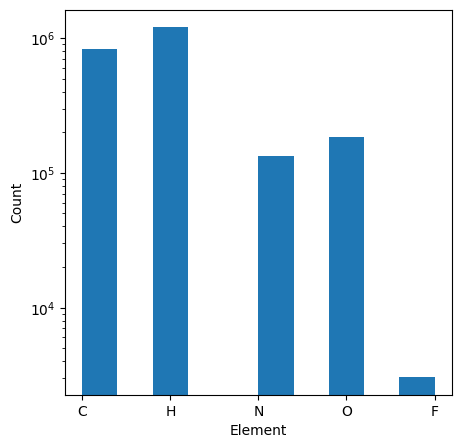

In [18]:
fig, ax = plt.subplots(figsize=(5,5))
ax.hist(atoms)
ax.set_xlabel('Element')
ax.set_ylabel('Count')
ax.set_yscale('log')

In [19]:
atoms.count('F')

3036

Much less fluorine than other elements so could influence performance evaluation - if train:test split is done randomly we could end up with all flourines in the test set. Still >3k examples so probably plenty to learn from.

A consideration here: do we explicitly include H atoms in our representations? Doing so increases graph size significantly; some models use no. H atoms as a dimension for atomic embeddings instead. No. H atoms is directly predictable from bond order and atom type

### Numbers of atoms per molecule

In [20]:
sizes = [len(data.x) for data in dataset]

Text(0, 0.5, 'Count')

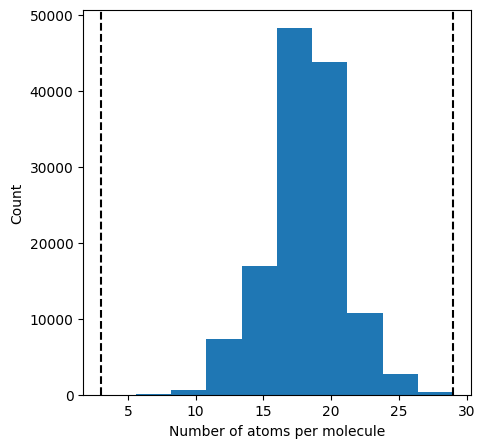

In [21]:
fig, ax = plt.subplots(figsize=(5,5))
ax.hist(sizes)
ax.vlines(min(sizes),0,1,linestyle='--',color='k',transform=ax.get_xaxis_transform())
ax.vlines(max(sizes),0,1,linestyle='--',color='k',transform=ax.get_xaxis_transform())
ax.set_xlabel('Number of atoms per molecule')
ax.set_ylabel('Count')

Nearly 30 atoms in some molecules, 3 in smallest. General distribution is fairly close to normal. Graphs with 30 atoms will be considerably larger than the smaller molecules, even using COO, so batching will need to be done carefully to avoid memory problems

Let's see how this distribution changes if we ignore H atoms

In [22]:
dataset[0].z.tolist().count(1)

4

In [23]:
h_free_sizes = [len(data.z) - data.z.tolist().count(1) for data in dataset]

Text(0, 0.5, 'Count')

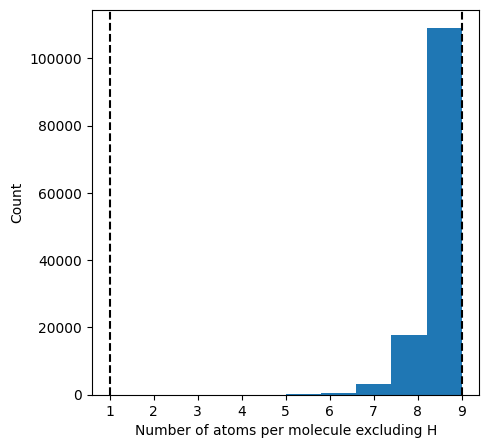

In [24]:
fig, ax = plt.subplots(figsize=(5,5))
ax.hist(h_free_sizes)
ax.vlines(min(h_free_sizes),0,1,linestyle='--',color='k',transform=ax.get_xaxis_transform())
ax.vlines(max(h_free_sizes),0,1,linestyle='--',color='k',transform=ax.get_xaxis_transform())
ax.set_xlabel('Number of atoms per molecule excluding H')
ax.set_ylabel('Count')

Certainly makes the graphs smaller, max is 9 as expected for QM9. Makes the distribution a lot more skewed.

### Bond Types
Are all bond types included in the dataset? If so, including edge attributes could enhance learning. If not, it may be add a lot of bulk to the model without improving performance much

In [25]:
dataset.edge_attr.shape

torch.Size([4883516, 4])

In [26]:
from collections import defaultdict

In [27]:
bond_counts = defaultdict(int)

In [28]:
bond_names = {0: "single", 1: "double", 2: "triple", 3:"aromatic"}

In [29]:
for i in range(4):
    name = bond_names.get(i, f"{i} in dict")
    bond_counts[name] = torch.sum(dataset.edge_attr[:,i]/2) # divide by 2 since bonds are between two atoms so will otherwise double count

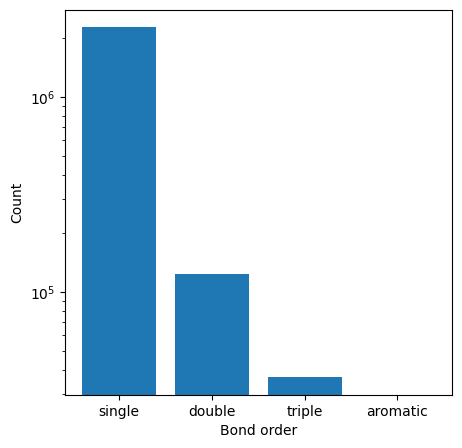

In [30]:
fig,ax = plt.subplots(figsize=(5,5))
ax.bar(bond_counts.keys(), bond_counts.values())
ax.set_xlabel('Bond order')
ax.set_ylabel('Count')
ax.set_yscale('log')

No aromatic bonds in the dataset! Otherwise distribution is extremely highly weighted towards single bonds, though that's probably representative of nature for small molecules. We could certain remove the fourth column of the edge attributes matrix, and there may not be enough double & triple bonds to be worth including. Including interatomic distances (at least for connected atoms) would provide more granularity between single bonds and help distinguish between single and double bonds e.g ethane C-C is 1.53 $\AA$ while ethene C-C is more like 1.34 $\AA$. If we include, will need to be careful to balance distributions of double & triple bonds in training vs test data

### Bond lengths

In [31]:
bond_lengths = []
for data in dataset:
    j_range = int(data.edge_index.shape[1]/2) # this dimension is 2 x no. unique edges
    for j in range(j_range):
        atom1 = data.edge_index[0,j]
        atom2 = data.edge_index[1,j]
        bond_lengths.append(math.dist(data.pos[atom1,:],data.pos[atom2,:]))

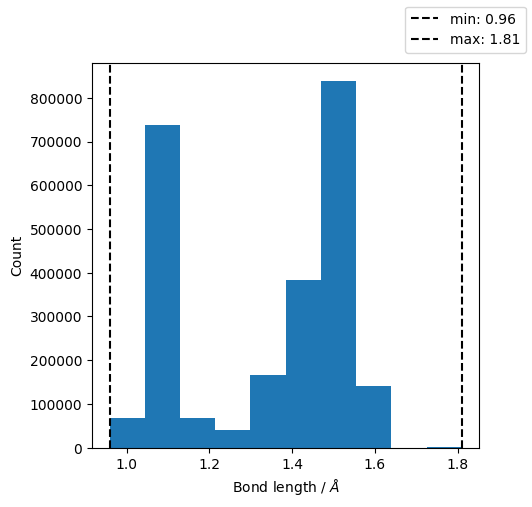

In [32]:
fig, ax = plt.subplots(figsize=(5,5))
ax.hist(bond_lengths)
ax.vlines(min(bond_lengths),0,1,linestyle='--',color='k',transform=ax.get_xaxis_transform(),label=f'min: {min(bond_lengths):.2f}')
ax.vlines(max(bond_lengths),0,1,linestyle='--',color='k',transform=ax.get_xaxis_transform(),label=f'max: {max(bond_lengths):.2f}')
ax.set_xlabel(r'Bond length / $\AA$')
ax.set_ylabel('Count')
fig.legend()

Bond distances are quite tightly bound between 0.96 and 1.81 $\AA$. Could use Gaussian expansion over distances in range [0.9,1.9]. However, this might be too specific to the dataset and hurt generalisability. Bonds aren't likely to get much smaller. In an MLIP we might want to allow for smaller distances, but for static molecules on which we're predicting static properties, it shouldn't matter. We might want to allow for longer bond distances, though depending on our spacing & sigma, the model wouldn't learn from much further centres. [0.8,2] Seems reasonable to allow for a little more generalisability

In [33]:
# e.g.
def RBF_expand_distance(distance: float, centres: np.array, sigma: float):
    return np.exp(-0.5*((distance - centres)/sigma)**2)


An 8-dimensional expansion should be fairly expressive while avoiding too many parameters. SchNet says they use spacing and scaling parameters of 0.1 $\AA$ even though they use $\exp(-\gamma(d-\mu_k)^2)$ which is dimensionally inconsistent - $\gamma$ should have units of $\AA^{-2}$

In [34]:
min_centre = 0.8
max_centre = 2
n_centres = 8
spacing = (max_centre-min_centre)/(n_centres-1)
grid = np.linspace(min_centre,max_centre,n_centres)
min_vec = RBF_expand_distance(0.96, grid,1*spacing)
max_vec = RBF_expand_distance(1.81, grid,1*spacing)
print(f"expanded distance for min distance: {min_vec}")
print(f"expanded distance for max distance: {max_vec}")

expanded distance for min distance: [6.46905175e-01 9.97780245e-01 5.66154150e-01 1.18178917e-01
 9.07508782e-03 2.56369989e-04 2.66433635e-06 1.01862993e-08]
expanded distance for max distance: [2.90029567e-08 6.36815105e-06 5.14386967e-04 1.52852334e-02
 1.67093559e-01 6.71974610e-01 9.94149128e-01 5.41072830e-01]


this seems reasonable - will construct so that n_centres and sigma/spacing are hyperparameters

### Target distribution

Text(0, 0.5, 'Count')

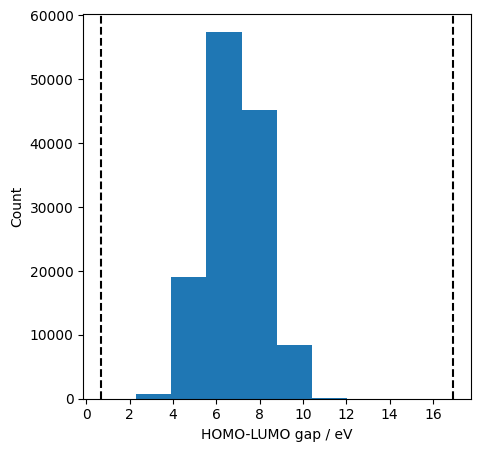

In [35]:
gaps = dataset.y[:, 4]
fig, ax = plt.subplots(figsize=(5,5))
ax.hist(gaps)
ax.vlines(min(gaps),0,1,linestyle='--',color='k',transform=ax.get_xaxis_transform())
ax.vlines(max(gaps),0,1,linestyle='--',color='k',transform=ax.get_xaxis_transform())
ax.set_xlabel('HOMO-LUMO gap / eV')
ax.set_ylabel('Count')

Almost normally distributed - suitable for z-scaling and should be well behaved. Extremum values are quite far from main distribution.

### Atomic embeddings

Let's see example feature vectors are for each element

In [36]:
feature_vectors = {}    
for i, el in atom_dict.items():
    for data in dataset[:200]:
        els = data.z.tolist()
        if i in els:
            index = els.index(i)
            feature_vectors[el] = data.x[index,:]
            break

In [37]:
feature_vectors

{'H': tensor([1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]),
 'C': tensor([0., 1., 0., 0., 0., 6., 0., 0., 0., 0., 4.]),
 'N': tensor([0., 0., 1., 0., 0., 7., 0., 0., 0., 0., 3.]),
 'O': tensor([0., 0., 0., 1., 0., 8., 0., 0., 0., 0., 2.]),
 'F': tensor([0., 0., 0., 0., 1., 9., 0., 0., 0., 0., 0.])}

From MPNN paper, these dimensions correspond to:
- 1-5: one-hots for [H,C,N,O,F]
- 6: atomic number
- 7: accepts electrons
- 8: donates electrons
- 9: aromatic
- 10: hybridization
- 11: N. hydrogens


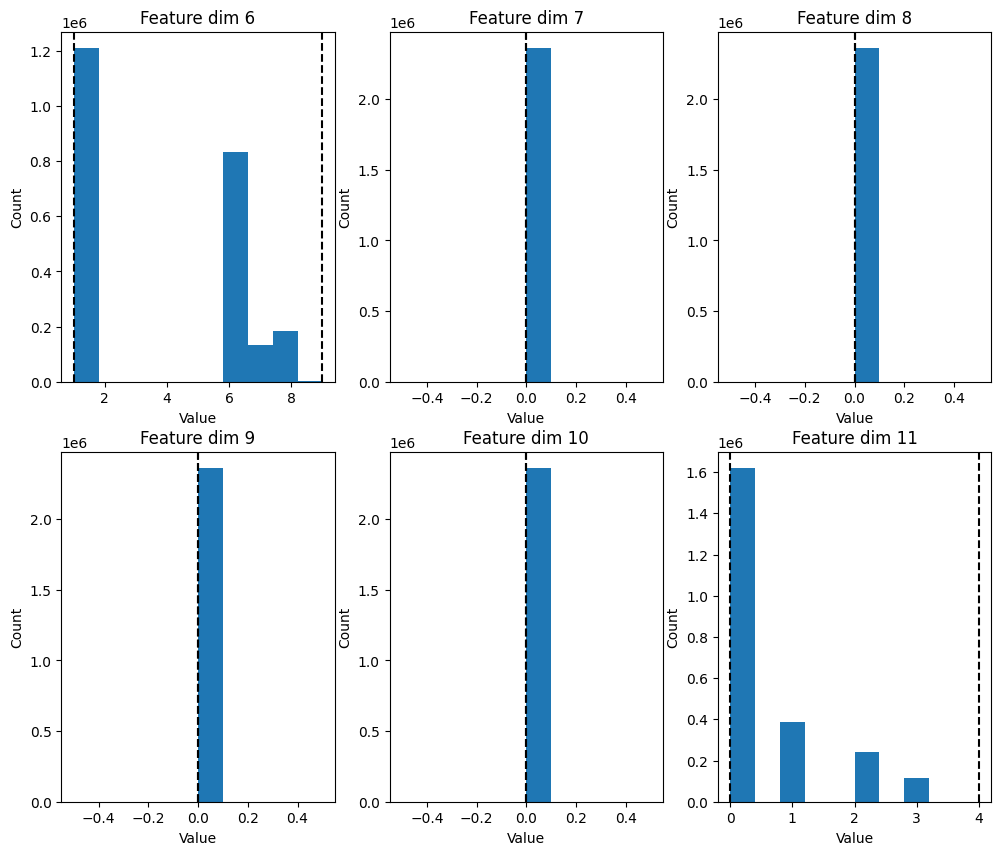

In [38]:
fig,axs = plt.subplots(2,3,figsize=(12,10))
for i, ax in enumerate(axs.flatten()):
    dim = i+5
    ax.hist(dataset.x[:,dim])
    ax.set_title(f'Feature dim {dim+1}')
    ax.vlines(min(dataset.x[:,dim]),0,1,linestyle='--',color='k',transform=ax.get_xaxis_transform())
    ax.vlines(max(dataset.x[:,dim]),0,1,linestyle='--',color='k',transform=ax.get_xaxis_transform())
    ax.set_ylabel('Count')
    ax.set_xlabel('Value')


Dimensions 7-10 seem redundant - they are 0 for every atom in every molecule. Unclear why this is. Feature 11, being the number of H atoms attached, could also be redundant if we explicitly include H atoms in the graph. Using Features 1-6 and 11 seems reasonable - we can then use a dense layer to increase that to e.g 16 for richer learned representations. Including the 11th dimension allows the atomic embeddings to distinguish between different environments for a given atom before any message passing even happens.